# Qwen Decomposition Pipeline (Text Seg + Eraser)

This notebook:
1) Runs local Qwen text-seg to extract a text mask.
2) Sends the image + mask to the remote text eraser endpoint.
3) Saves mask / erased / visualization outputs.

Set `INPUT_IMAGE_PATH` (or `INPUT_ROOT` for batch) and run all cells.


In [1]:
import base64
import glob
import io
import os
from pathlib import Path
from typing import Optional, Union

import requests
import torch
from IPython.display import display
from PIL import Image
from tqdm.auto import tqdm

from diffsynth.pipelines.qwen_image import QwenImagePipeline, ModelConfig
from diffsynth import load_state_dict

CUDA_DEVICE_INDEX = 0
if torch.cuda.is_available():
    torch.cuda.set_device(CUDA_DEVICE_INDEX)
    DEVICE = torch.device(f"cuda:{CUDA_DEVICE_INDEX}")
    TORCH_DTYPE = torch.bfloat16
else:
    DEVICE = torch.device("cpu")
    TORCH_DTYPE = torch.float32

print(f"[device] {DEVICE} (dtype={TORCH_DTYPE})")


def _find_repo_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "diffsynth").exists() and (parent / "pyproject.toml").exists():
            return parent
    return start


def _resolve_model_base(repo_root: Path) -> Path:
    env = os.environ.get("DIFFSYNTH_MODEL_BASE_PATH", "/mnt/local/diffsynth_models")
    if env:
        return Path(env)
    candidates = [
        repo_root / "diffsynth_models",
        Path("/mnt/lica-data-2/for_jjseol/diffsynth_models"),
        Path("/mnt/data/for_jjseol/diffsynth_models"),
    ]
    for cand in candidates:
        if (cand / "Qwen").exists():
            return cand
    return candidates[0]

DEFAULT_GUIDANCE_SCALE = 15.0
DEFAULT_NUM_INFERENCE_STEPS = 28
DEFAULT_MASK_DILATION_RADIUS = 3
DEFAULT_MAX_SIDE_LENGTH = 1920


REPO_ROOT = _find_repo_root(Path(".").resolve())
MODEL_BASE = _resolve_model_base(REPO_ROOT)
print(f"[model] base: {MODEL_BASE}")

PROMPT = "Extract the text layer."
SEED = 123
STEPS = 20

FULL_CKPT_DIR = REPO_ROOT / "models/train/Qwen-Image-Edit-2511_full_layered_vae_text_seg"
FULL_CKPT = FULL_CKPT_DIR / "epoch-0-20k.safetensors"

OUTPUT_ROOT = REPO_ROOT / "output/qwen_decomposition"
MASK_DIR = OUTPUT_ROOT / "mask"
ERASED_DIR = OUTPUT_ROOT / "erased"
VIS_DIR = OUTPUT_ROOT / "visualization"
MASK_DIR.mkdir(parents=True, exist_ok=True)
ERASED_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff"}


[device] cuda:0 (dtype=torch.bfloat16)
[model] base: /mnt/local/diffsynth_models


In [6]:
def _model_config_local_only(local_glob: str, label: str) -> ModelConfig:
    paths = sorted(glob.glob(local_glob))
    if not paths:
        raise FileNotFoundError(f"[model] Missing local weights for {label}: {local_glob}")
    path_value = paths if len(paths) > 1 else paths[0]
    print(f"[model] Using local weights: {path_value}")
    return ModelConfig(path=path_value)


def _aux_config_local_only(local_dir: Path, label: str) -> ModelConfig:
    if not local_dir.exists():
        raise FileNotFoundError(f"[aux] Missing local assets for {label}: {local_dir}")
    print(f"[aux] Using local assets: {local_dir}")
    return ModelConfig(path=str(local_dir))


def _resolve_ckpt_path(path: Path) -> Path:
    if path.is_dir():
        candidates = sorted(path.glob("*.safetensors"), key=lambda p: p.stat().st_mtime)
        if not candidates:
            raise FileNotFoundError(f"No checkpoints found in: {path}")
        return candidates[-1]
    return path


def build_text_seg_pipeline() -> QwenImagePipeline:
    qwen_root = MODEL_BASE / "Qwen"
    pipe = QwenImagePipeline.from_pretrained(
        torch_dtype=TORCH_DTYPE,
        device=str(DEVICE),
        model_configs=[
            _model_config_local_only(
                str(qwen_root / "Qwen-Image-Edit-2511" / "transformer" / "diffusion_pytorch_model-*.safetensors"),
                "Qwen-Image-Edit-2511 transformer",
            ),
            _model_config_local_only(
                str(qwen_root / "Qwen-Image" / "text_encoder" / "model*.safetensors"),
                "Qwen-Image text encoder",
            ),
            _model_config_local_only(
                str(qwen_root / "Qwen-Image-Layered" / "vae" / "diffusion_pytorch_model.safetensors"),
                "Qwen-Image-Layered VAE",
            ),
        ],
        tokenizer_config=None,
        processor_config=_aux_config_local_only(
            qwen_root / "Qwen-Image-Edit" / "processor",
            "Qwen-Image-Edit processor",
        ),
    )

    ckpt_path = _resolve_ckpt_path(FULL_CKPT_DIR if FULL_CKPT_DIR.exists() else FULL_CKPT)
    print(f"[ckpt] Using full checkpoint: {ckpt_path}")
    state_dict = load_state_dict(str(ckpt_path))
    pipe.dit.load_state_dict(state_dict)
    return pipe

def _resize_edit_image(image: Image.Image, max_side: int = 1024, round_to: int = 32) -> Image.Image:
    w, h = image.size
    scale = min(1.0, max_side / max(w, h))
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    if round_to:
        new_w = max(round_to, (new_w // round_to) * round_to)
        new_h = max(round_to, (new_h // round_to) * round_to)
    if (new_w, new_h) != (w, h):
        image = image.resize((new_w, new_h), Image.LANCZOS)
    return image


def run_text_segmentation(
    pipe: QwenImagePipeline,
    image_path: Path,
    *,
    prompt: str = PROMPT,
    seed: int = SEED,
    steps: int = STEPS,
    max_side: int = 1024,
    round_to: int = 32,
    edit_image_auto_resize: bool = False,
    mask_threshold: int = 20,
    save_mask_path: Optional[Path] = None,
) -> dict:
    if not image_path.exists():
        raise FileNotFoundError(f"Input image not found: {image_path}")

    edit_image = Image.open(image_path).convert("RGBA")
    orig_size = edit_image.size
    edit_image = _resize_edit_image(edit_image, max_side=max_side, round_to=round_to)
    width, height = edit_image.size

    result = pipe(
        prompt,
        edit_image=edit_image,
        seed=seed,
        num_inference_steps=steps,
        height=height,
        width=width,
        edit_image_auto_resize=edit_image_auto_resize,
        zero_cond_t=True,
    )

    output_rgba = result.convert("RGBA")
    alpha = output_rgba.getchannel("A")
    mask = alpha.point(lambda v: 255 if v > mask_threshold else 0)

    if mask.size != orig_size:
        mask = mask.resize(orig_size, Image.NEAREST)

    if save_mask_path is not None:
        save_mask_path.parent.mkdir(parents=True, exist_ok=True)
        mask.save(save_mask_path)

    return {
        "mask": mask,
        "output_rgba": output_rgba,
        "orig_size": orig_size,
    }


def _load_image_input(image_input: Union[str, Path, Image.Image], mode: str = "RGB") -> Image.Image:
    if isinstance(image_input, Image.Image):
        return image_input.convert(mode)
    path = Path(image_input)
    return Image.open(path).convert(mode)


def _load_mask_input(mask_input: Union[str, Path, Image.Image]) -> Image.Image:
    if mask_input is None:
        raise ValueError("mask_input must not be None")
    if isinstance(mask_input, Image.Image):
        return mask_input.convert("L")
    path = Path(mask_input)
    return Image.open(path).convert("L")


def _encode_image_to_base64(image_input: Union[str, Path, Image.Image], mode: str = "RGB") -> tuple[str, Image.Image]:
    image = _load_image_input(image_input, mode=mode)
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8"), image


def _encode_mask_to_base64(
    mask_input: Union[str, Path, Image.Image], *, match_size: Optional[Image.Image] = None
) -> str:
    mask = _load_mask_input(mask_input)
    if match_size is not None and mask.size != match_size.size:
        mask = mask.resize(match_size.size, Image.NEAREST)
    buffer = io.BytesIO()
    mask.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")


def _decode_image_from_base64(data: str, mode: str = "RGB") -> Image.Image:
    return Image.open(io.BytesIO(base64.b64decode(data))).convert(mode)


def build_payload(
    image_input: Union[str, Path, Image.Image],
    *,
    mask_input: Optional[Union[str, Path, Image.Image]] = None,
    guidance_scale: float = DEFAULT_GUIDANCE_SCALE,
    num_inference_steps: int = DEFAULT_NUM_INFERENCE_STEPS,
    mask_dilation_radius: int = DEFAULT_MASK_DILATION_RADIUS,
    max_side_length: int = DEFAULT_MAX_SIDE_LENGTH,
) -> dict[str, object]:
    image_b64, image_obj = _encode_image_to_base64(image_input)
    payload: dict[str, object] = {
        "image": image_b64,
        "guidance_scale": guidance_scale,
        "num_inference_steps": num_inference_steps,
        "mask_dilation_radius": mask_dilation_radius,
        "max_side_length": max_side_length,
    }
    if mask_input is not None:
        payload["mask"] = _encode_mask_to_base64(mask_input, match_size=image_obj)
    return payload


def invoke_remote(payload: dict[str, object], label: str = "remote") -> dict[str, object]:
    if not BASETEN_API_KEY:
        raise ValueError("BASETEN_API_KEY is missing. Set env var or update notebook.")
    print(f"[info] Invoking {BASETEN_ENDPOINT} ({label})")
    response = remote_client.post(BASETEN_ENDPOINT, json=payload, timeout=180)
    response.raise_for_status()
    data: dict[str, object] = response.json()
    for key in ("output", "result", "prediction", "response"):
        nested = data.get(key) if isinstance(data, dict) else None
        if isinstance(nested, dict):
            data = nested
            break

    remote_image = _decode_image_from_base64(str(data["image_base64"]))
    remote_mask = _decode_image_from_base64(str(data["mask_base64"]), mode="L")

    data["_image_obj"] = remote_image
    data["_mask_obj"] = remote_mask
    return data


def save_visualization(input_image: Image.Image, mask: Image.Image, erased: Image.Image, out_path: Path) -> None:
    if input_image.size != erased.size:
        input_image = input_image.resize(erased.size, Image.LANCZOS)
    if mask.size != erased.size:
        mask = mask.resize(erased.size, Image.NEAREST)

    mask_rgb = mask.convert("RGB")
    canvas = Image.new("RGB", (erased.width * 3, erased.height), (0, 0, 0))
    canvas.paste(input_image, (0, 0))
    canvas.paste(mask_rgb, (erased.width, 0))
    canvas.paste(erased, (erased.width * 2, 0))
    canvas.save(out_path)

def _iter_images(root: Path):
    if not root.exists():
        raise FileNotFoundError(f"Input root not found: {root}")
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS:
            yield path


def _build_output_paths(image_path: Path, rel: Optional[Path] = None) -> dict:
    rel = rel or Path(image_path.name)
    mask_path = MASK_DIR / rel.parent / f"{image_path.stem}_mask.png"
    erased_path = ERASED_DIR / rel.parent / f"{image_path.stem}_erased.png"
    vis_path = VIS_DIR / rel.parent / f"{image_path.stem}_viz.png"
    return {
        "mask_path": mask_path,
        "erased_path": erased_path,
        "vis_path": vis_path,
    }

def run_decomposition_pipeline(
    image_path: Path,
    pipe: QwenImagePipeline,
    *,
    rel: Optional[Path] = None,
    skip_existing: bool = True,
    prompt: str = PROMPT,
    seed: int = SEED,
    steps: int = STEPS,
    mask_threshold: int = 20,
    max_side: int = 1024,
    round_to: int = 32,
    edit_image_auto_resize: bool = False,
    guidance_scale: float = DEFAULT_GUIDANCE_SCALE,
    num_inference_steps: int = DEFAULT_NUM_INFERENCE_STEPS,
    mask_dilation_radius: int = DEFAULT_MASK_DILATION_RADIUS,
    max_side_length: int = DEFAULT_MAX_SIDE_LENGTH,
    show_preview: bool = False,
) -> dict:
    paths = _build_output_paths(image_path, rel=rel)
    mask_path = paths["mask_path"]
    erased_path = paths["erased_path"]
    vis_path = paths["vis_path"]

    if skip_existing and erased_path.exists() and mask_path.exists() and vis_path.exists():
        return {
            "mask_path": mask_path,
            "erased_path": erased_path,
            "vis_path": vis_path,
            "skipped": True,
        }

    seg = run_text_segmentation(
        pipe,
        image_path,
        prompt=prompt,
        seed=seed,
        steps=steps,
        max_side=max_side,
        round_to=round_to,
        edit_image_auto_resize=edit_image_auto_resize,
        mask_threshold=mask_threshold,
        save_mask_path=mask_path,
    )
    mask = seg["mask"]

    payload = build_payload(
        image_path,
        mask_input=mask,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps,
        mask_dilation_radius=mask_dilation_radius,
        max_side_length=max_side_length,
    )
    result = invoke_remote(payload, label=rel.as_posix() if rel else image_path.stem)
    erased = result["_image_obj"]

    erased_path.parent.mkdir(parents=True, exist_ok=True)
    erased.save(erased_path)

    input_image = _load_image_input(image_path, mode="RGB")
    vis_path.parent.mkdir(parents=True, exist_ok=True)
    save_visualization(input_image, mask, erased, vis_path)

    if show_preview:
        display(Image.open(vis_path))

    return {
        "mask": mask,
        "erased": erased,
        "mask_path": mask_path,
        "erased_path": erased_path,
        "vis_path": vis_path,
        "skipped": False,
    }
BASETEN_ENDPOINT = "https://model-yqvdk1eq.api.baseten.co/environments/production/predict"
BASETEN_API_KEY = os.environ.get(
    "BASETEN_API_KEY",
    "ZMuoM428.x26ObfkmoAx2Lnn6VGcqqxOIRupKdYYu",
)

remote_client = requests.Session()
remote_client.headers.update(
    {
        "Content-Type": "application/json",
        "Authorization": f"Api-Key {BASETEN_API_KEY}",
    }
)



In [3]:
SEG_MAX_SIDE = 1024
SEG_ROUND_TO = 32
SEG_EDIT_IMAGE_AUTO_RESIZE = False
MASK_THRESHOLD = 20
STEPS = 20

ERASER_GUIDANCE_SCALE = DEFAULT_GUIDANCE_SCALE
ERASER_NUM_INFERENCE_STEPS = DEFAULT_NUM_INFERENCE_STEPS
ERASER_MASK_DILATION_RADIUS = DEFAULT_MASK_DILATION_RADIUS
ERASER_MAX_SIDE_LENGTH = DEFAULT_MAX_SIDE_LENGTH

SKIP_EXISTING = True

pipe = build_text_seg_pipeline()


[model] Using local weights: ['/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00001-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00002-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00003-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00004-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00005-of-00005.safetensors']
[model] Using local weights: ['/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00001-of-00004.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00002-of-00004.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00003-of-00004.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/mod

Loaded model: {
    "model_name": "qwen_image_dit",
    "model_class": "diffsynth.models.qwen_image_dit.QwenImageDiT",
    "extra_kwargs": null
}
Loading models from: [
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00001-of-00004.safetensors",
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00002-of-00004.safetensors",
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00003-of-00004.safetensors",
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00004-of-00004.safetensors"
]
Loaded model: {
    "model_name": "qwen_image_text_encoder",
    "model_class": "diffsynth.models.qwen_image_text_encoder.QwenImageTextEncoder",
    "extra_kwargs": null
}
Loading models from: "/mnt/local/diffsynth_models/Qwen/Qwen-Image-Layered/vae/diffusion_pytorch_model.safetensors"
Loaded model: {
    "model_name": "qwen_image_vae",
    "model_class": "diffsynth.models.qwen_image_vae.QwenImageVAE",
    "extra_kwargs": {
        "image

In [7]:
RUN_BATCH = False
INPUT_IMAGE_PATH = Path("/home/ubuntu/original_input.png")
INPUT_ROOT = Path("/path/to/your/images")

[info] skipped existing outputs
[done] mask: /home/ubuntu/DiffSynth-Studio/output/qwen_decomposition/mask/original_input_mask.png
[done] erased: /home/ubuntu/DiffSynth-Studio/output/qwen_decomposition/erased/original_input_erased.png
[done] viz: /home/ubuntu/DiffSynth-Studio/output/qwen_decomposition/visualization/original_input_viz.png
[done] last erased path: /home/ubuntu/DiffSynth-Studio/output/qwen_decomposition/erased/original_input_erased.png


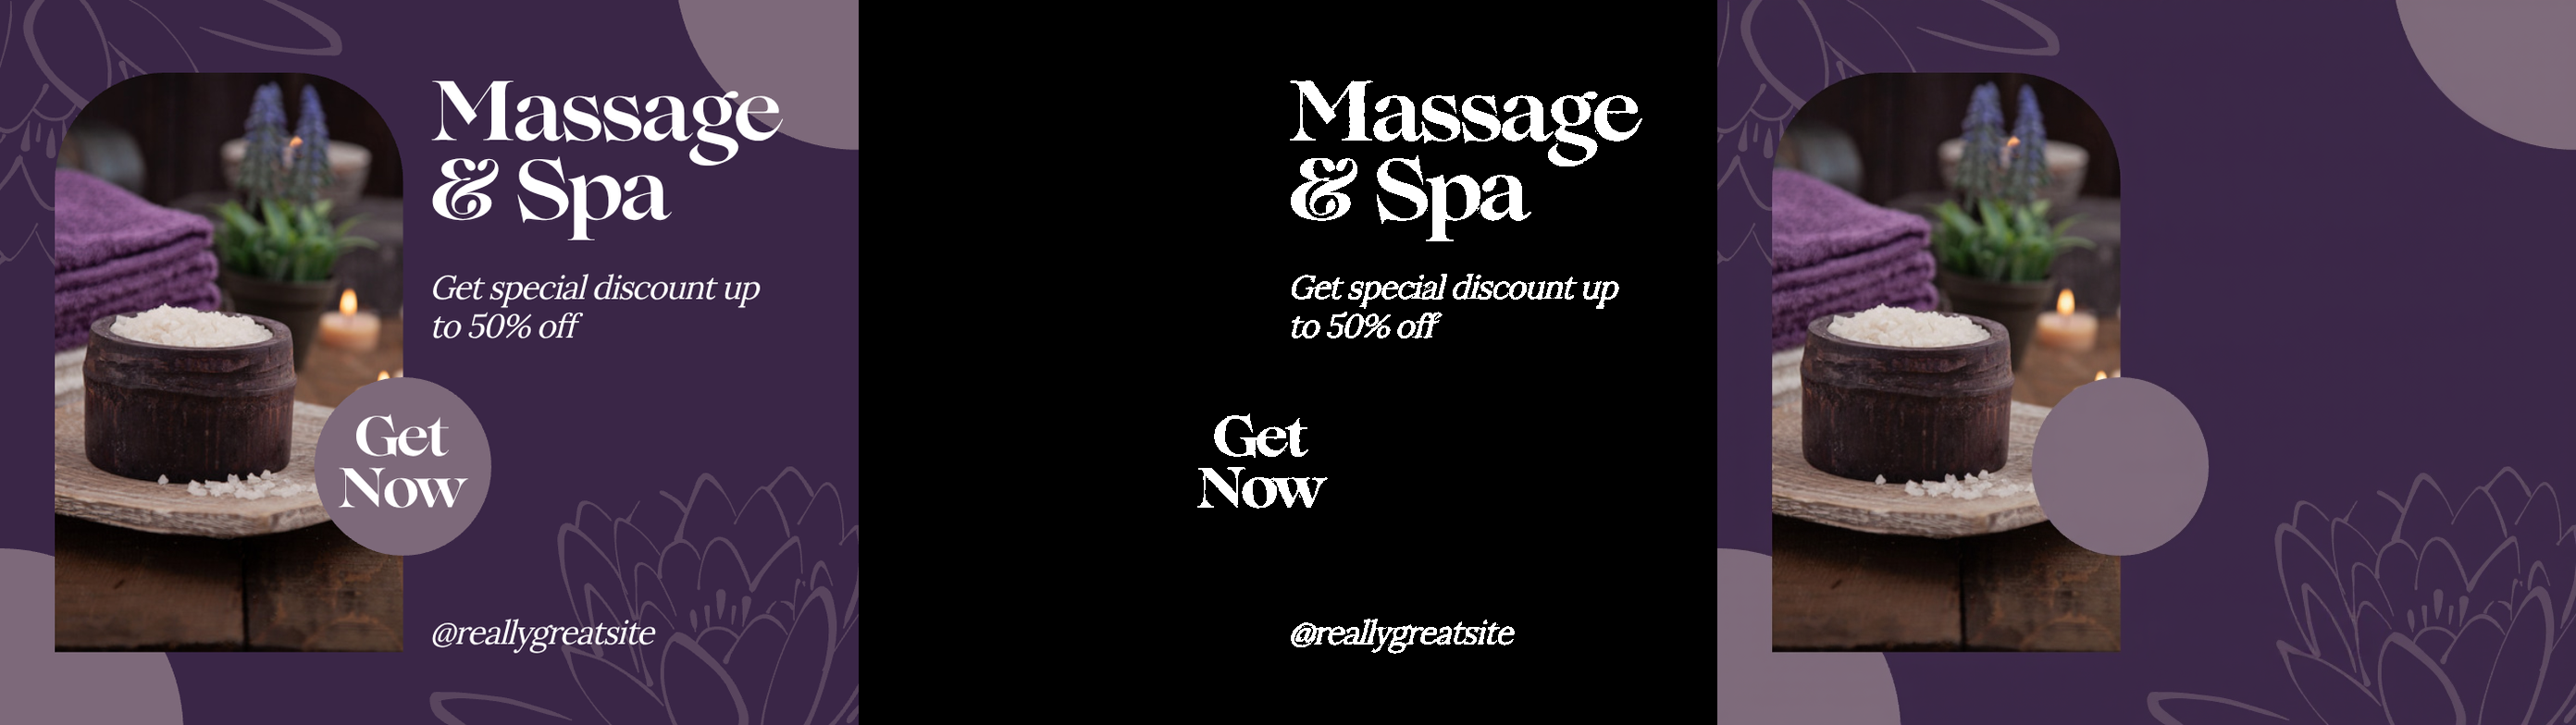

In [8]:
if "pipe" not in globals():
    pipe = build_text_seg_pipeline()

if RUN_BATCH:
    image_paths = sorted(_iter_images(INPUT_ROOT))
    if not image_paths:
        raise FileNotFoundError(f"No images found under: {INPUT_ROOT}")

    skipped = 0
    for idx, path in enumerate(tqdm(image_paths, desc="decompose")):
        rel = path.relative_to(INPUT_ROOT)
        result = run_decomposition_pipeline(
            path,
            pipe,
            rel=rel,
            skip_existing=SKIP_EXISTING,
            seed=SEED + idx,
            steps=STEPS,
            mask_threshold=MASK_THRESHOLD,
            max_side=SEG_MAX_SIDE,
            round_to=SEG_ROUND_TO,
            edit_image_auto_resize=SEG_EDIT_IMAGE_AUTO_RESIZE,
            guidance_scale=ERASER_GUIDANCE_SCALE,
            num_inference_steps=ERASER_NUM_INFERENCE_STEPS,
            mask_dilation_radius=ERASER_MASK_DILATION_RADIUS,
            max_side_length=ERASER_MAX_SIDE_LENGTH,
        )
        if result.get("skipped"):
            skipped += 1

    print(f"[done] outputs saved under: {OUTPUT_ROOT}")
    if skipped:
        print(f"[info] skipped existing: {skipped}")
else:
    if not INPUT_IMAGE_PATH.exists():
        raise FileNotFoundError(f"Input image not found: {INPUT_IMAGE_PATH}")

    SHOW_PREVIEW = globals().get("SHOW_PREVIEW", True)

    result = run_decomposition_pipeline(
        INPUT_IMAGE_PATH,
        pipe,
        skip_existing=SKIP_EXISTING,
        seed=SEED,
        steps=STEPS,
        mask_threshold=MASK_THRESHOLD,
        max_side=SEG_MAX_SIDE,
        round_to=SEG_ROUND_TO,
        edit_image_auto_resize=SEG_EDIT_IMAGE_AUTO_RESIZE,
        guidance_scale=ERASER_GUIDANCE_SCALE,
        num_inference_steps=ERASER_NUM_INFERENCE_STEPS,
        mask_dilation_radius=ERASER_MASK_DILATION_RADIUS,
        max_side_length=ERASER_MAX_SIDE_LENGTH,
        show_preview=False,
    )

    if result.get("skipped"):
        print("[info] skipped existing outputs")
    print(f"[done] mask: {result['mask_path']}")
    print(f"[done] erased: {result['erased_path']}")
    print(f"[done] viz: {result['vis_path']}")
    LAST_ERASED_PATH = result["erased_path"]
    print(f"[done] last erased path: {LAST_ERASED_PATH}")

    if SHOW_PREVIEW:
        display(Image.open(result["vis_path"]))

# Iterative Decomposition

In [9]:
# Iterative FG-seg -> eraser loop (stops when FG mask is empty)
import base64
import io
import os
import traceback
from datetime import datetime
from pathlib import Path

import requests
import torch
from IPython.display import display
from PIL import Image

from diffsynth.pipelines.qwen_image import QwenImagePipeline, ModelConfig


# ----------------------
# Basic config
# ----------------------
# Leave as None to auto-resolve from INPUT_IMAGE_PATH / LAST_ERASED_PATH
TEXT_ERASED_IMAGE_PATH = None
MAX_ITERS = 5
SHOW_PREVIEW = True

# FG-seg config
FG_CUDA_DEVICE_INDEX = 1
FG_PROMPT = "Extract the foreground layer."
FG_STEPS = 10
FG_MASK_THRESHOLD = 20
FG_MIN_PIXELS = 1
FG_USE_LORA = True

DIFFSYNTH_REPO_ROOT = Path(os.environ.get("DIFFSYNTH_REPO_ROOT", "/home/ubuntu/DiffSynth-Studio"))
DIFFSYNTH_MODEL_BASE = Path(os.environ.get("DIFFSYNTH_MODEL_BASE_PATH", "/mnt/local/diffsynth_models"))

FG_LORA_DIR = DIFFSYNTH_REPO_ROOT / "models/train/Qwen-Image-Edit-2511_lora_layered_vae_fg_seg"
FG_LORA_PATH = FG_LORA_DIR / "epoch-0.safetensors"

# Eraser config (Baseten; from object-eraser test.ipynb)
ERASER_GUIDANCE_SCALE = 15.0
ERASER_NUM_INFERENCE_STEPS = 28
ERASER_MASK_DILATION_RADIUS = 3
ERASER_MAX_SIDE_LENGTH = 1920
ERASER_PROMPT = ""
ERASER_SEED = None

API_ENDPOINT = "https://model-vq0244mw.api.baseten.co/environments/production/predict"
API_KEY = os.environ.get("BASETEN_API_KEY", "CKwNJ4Yo.ZNOklLwjh9kWyOj5yYeooT0jvjxXwu9P")

OUTPUT_ROOT = globals().get("OUTPUT_ROOT", DIFFSYNTH_REPO_ROOT / "output/qwen_decomposition")
ERASED_DIR = globals().get("ERASED_DIR", OUTPUT_ROOT / "erased")
ERASED_DIR.mkdir(parents=True, exist_ok=True)
ITER_OUTPUT_ROOT = OUTPUT_ROOT / "iterative_fg_eraser"
ITER_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
ERROR_LOG_PATH = ITER_OUTPUT_ROOT / "iterative_fg_eraser_errors.log"


# ----------------------
# Helpers
# ----------------------
if "_model_config_local_only" not in globals():
    def _model_config_local_only(local_glob: str, label: str) -> ModelConfig:
        import glob

        paths = sorted(glob.glob(local_glob))
        if not paths:
            raise FileNotFoundError(f"[model] Missing local weights for {label}: {local_glob}")
        path_value = paths if len(paths) > 1 else paths[0]
        print(f"[model] Using local weights: {path_value}")
        return ModelConfig(path=path_value)

if "_aux_config_local_only" not in globals():
    def _aux_config_local_only(local_dir: Path, label: str) -> ModelConfig:
        if not local_dir.exists():
            raise FileNotFoundError(f"[aux] Missing local assets for {label}: {local_dir}")
        print(f"[aux] Using local assets: {local_dir}")
        return ModelConfig(path=str(local_dir))


def decode_image_from_base64(data: str, mode: str = "RGB") -> Image.Image:
    return Image.open(io.BytesIO(base64.b64decode(data))).convert(mode)


def encode_path_to_base64(path: Path, *, mode: str = "RGB") -> str:
    image = Image.open(path).convert(mode)
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")


def _composite_side_by_side(images: list[Image.Image]) -> Image.Image:
    heights = [img.height for img in images]
    target_height = max(heights)

    resized: list[Image.Image] = []
    for img in images:
        if img.height == target_height:
            resized.append(img)
        else:
            new_width = max(1, int(round(img.width * (target_height / img.height))))
            resample = Image.NEAREST if img.mode == "L" else Image.LANCZOS
            resized.append(img.resize((new_width, target_height), resample))

    total_width = sum(img.width for img in resized)
    composite = Image.new("RGB", (total_width, target_height))
    offset = 0
    for img in resized:
        paste_img = img if img.mode == "RGB" else Image.merge("RGB", (img, img, img))
        composite.paste(paste_img, (offset, 0))
        offset += paste_img.width
    return composite


def _log_error(stage: str, exc: Exception) -> None:
    timestamp = datetime.now().isoformat(timespec="seconds")
    message = f"[{timestamp}] stage={stage} error={exc}\n{traceback.format_exc()}\n"
    with ERROR_LOG_PATH.open("a") as f:
        f.write(message)
    print(f"[error] {stage}: {exc} (see {ERROR_LOG_PATH})")


def _resolve_text_erased_path() -> Path:
    if TEXT_ERASED_IMAGE_PATH:
        return Path(TEXT_ERASED_IMAGE_PATH)
    if "LAST_ERASED_PATH" in globals():
        candidate = Path(str(globals()["LAST_ERASED_PATH"]))
        if candidate.exists():
            return candidate
    if "INPUT_IMAGE_PATH" in globals():
        input_path = Path(str(globals()["INPUT_IMAGE_PATH"]))
        return ERASED_DIR / f"{input_path.stem}_erased.png"
    raise FileNotFoundError(
        "TEXT_ERASED_IMAGE_PATH is not set. Update INPUT_IMAGE_PATH or set TEXT_ERASED_IMAGE_PATH."
    )


def build_fg_seg_pipeline(device_index: int = FG_CUDA_DEVICE_INDEX) -> QwenImagePipeline:
    if torch.cuda.is_available():
        torch.cuda.set_device(device_index)
        fg_device = f"cuda:{device_index}"
        fg_dtype = torch.bfloat16
    else:
        fg_device = "cpu"
        fg_dtype = torch.float32

    print(f"[fg] device: {fg_device}")

    qwen_root = DIFFSYNTH_MODEL_BASE / "Qwen"
    pipe = QwenImagePipeline.from_pretrained(
        torch_dtype=fg_dtype,
        device=fg_device,
        model_configs=[
            _model_config_local_only(
                str(qwen_root / "Qwen-Image-Edit-2511" / "transformer" / "diffusion_pytorch_model-*.safetensors"),
                "Qwen-Image-Edit-2511 transformer",
            ),
            _model_config_local_only(
                str(qwen_root / "Qwen-Image" / "text_encoder" / "model*.safetensors"),
                "Qwen-Image text encoder",
            ),
            _model_config_local_only(
                str(qwen_root / "Qwen-Image-Layered" / "vae" / "diffusion_pytorch_model.safetensors"),
                "Qwen-Image-Layered VAE",
            ),
        ],
        tokenizer_config=None,
        processor_config=_aux_config_local_only(
            qwen_root / "Qwen-Image-Edit" / "processor",
            "Qwen-Image-Edit processor",
        ),
    )

    if FG_USE_LORA:
        if FG_LORA_DIR.is_dir():
            lora_candidates = sorted(FG_LORA_DIR.glob("*.safetensors"), key=lambda p: p.stat().st_mtime)
            if not lora_candidates:
                raise FileNotFoundError(f"No LoRA checkpoints found in: {FG_LORA_DIR}")
            lora_path = lora_candidates[-1]
        else:
            lora_path = FG_LORA_PATH

        if not lora_path.exists():
            raise FileNotFoundError(f"LoRA checkpoint not found: {lora_path}")

        print(f"[fg] Using LoRA: {lora_path}")
        pipe.load_lora(pipe.dit, str(lora_path))

    return pipe


def run_fg_seg_mask(image_path: Path, pipe: QwenImagePipeline, seed: int | None) -> Image.Image:
    edit_image = Image.open(image_path).convert("RGBA")
    width, height = edit_image.size

    result = pipe(
        FG_PROMPT,
        edit_image=edit_image,
        seed=seed,
        num_inference_steps=FG_STEPS,
        height=height,
        width=width,
        edit_image_auto_resize=False,
        zero_cond_t=True,
    )

    output_rgba = result.convert("RGBA")
    alpha = output_rgba.getchannel("A")
    mask = alpha.point(lambda v: 255 if v > FG_MASK_THRESHOLD else 0)

    if mask.size != edit_image.size:
        mask = mask.resize(edit_image.size, Image.NEAREST)

    return mask


def invoke_remote_api(
    *,
    image_path: Path,
    mask_path: Path,
    guidance_scale: float,
    num_inference_steps: int,
    mask_dilation_radius: int,
    max_side_length: int,
    prompt: str = "",
    seed: int | None = None,
) -> dict[str, object]:
    if not API_KEY:
        raise ValueError("Missing API_KEY. Set BASETEN_API_KEY or update API_KEY.")

    payload: dict[str, object] = {
        "image": encode_path_to_base64(image_path, mode="RGB"),
        "mask": encode_path_to_base64(mask_path, mode="L"),
        "guidance_scale": guidance_scale,
        "num_inference_steps": num_inference_steps,
        "mask_dilation_radius": mask_dilation_radius,
        "max_side_length": max_side_length,
    }
    if prompt:
        payload["prompt"] = prompt
    if seed is not None:
        payload["seed"] = int(seed)

    remote_client = requests.Session()
    remote_client.headers.update(
        {
            "Authorization": f"Api-Key {API_KEY}",
            "Content-Type": "application/json",
        }
    )

    print(f"[info] POST {API_ENDPOINT}")
    response = remote_client.post(API_ENDPOINT, json=payload, timeout=180)
    response.raise_for_status()
    data: dict[str, object] = response.json()
    for key in ("output", "result", "prediction", "response"):
        nested = data.get(key) if isinstance(data, dict) else None
        if isinstance(nested, dict):
            data = nested
            break
    return data


# ----------------------
# Run loop
# ----------------------
resolved_path = _resolve_text_erased_path()
if not resolved_path.exists():
    raise FileNotFoundError(f"Input text-erased image not found: {resolved_path}")

if "fg_pipe" not in globals():
    fg_pipe = build_fg_seg_pipeline()

current_path = resolved_path
base_seed = globals().get("SEED", 123)

for i in range(MAX_ITERS):
    iter_dir = ITER_OUTPUT_ROOT / f"iter_{i:02d}"
    iter_dir.mkdir(parents=True, exist_ok=True)

    try:
        mask = run_fg_seg_mask(current_path, fg_pipe, seed=base_seed + i)
    except Exception as exc:
        _log_error(f"fg-seg iter={i}", exc)
        break

    fg_pixels = mask.histogram()[255]
    if fg_pixels < FG_MIN_PIXELS:
        print(f"[stop] no fg mask at iter {i}")
        break

    mask_path = iter_dir / f"{current_path.stem}_fg_mask.png"
    mask.save(mask_path)

    try:
        result = invoke_remote_api(
            image_path=current_path,
            mask_path=mask_path,
            guidance_scale=ERASER_GUIDANCE_SCALE,
            num_inference_steps=ERASER_NUM_INFERENCE_STEPS,
            mask_dilation_radius=ERASER_MASK_DILATION_RADIUS,
            max_side_length=ERASER_MAX_SIDE_LENGTH,
            prompt=ERASER_PROMPT,
            seed= None, # ERASER_SEED if ERASER_SEED is not None else base_seed + i,
        )
    except Exception as exc:
        _log_error(f"eraser iter={i}", exc)
        break

    if "image_base64" not in result:
        _log_error(f"eraser iter={i}", RuntimeError("missing image_base64 in response"))
        break

    output_image = decode_image_from_base64(str(result["image_base64"]))
    output_path = iter_dir / f"{current_path.stem}_erased.png"
    output_image.save(output_path)

    input_image = Image.open(current_path).convert("RGB")
    output_image = output_image.resize(input_image.size, Image.LANCZOS)
    mask_vis = mask.resize(input_image.size, Image.NEAREST)
    composite = _composite_side_by_side([input_image, mask_vis, output_image])

    composite_path = iter_dir / f"{current_path.stem}_composite.png"
    composite.save(composite_path)

    print(f"[done] iter {i}: {composite_path}")
    if SHOW_PREVIEW:
        display(composite)

    current_path = output_path

print(f"[done] outputs saved under: {ITER_OUTPUT_ROOT}")
print(f"[done] error log: {ERROR_LOG_PATH}")


[fg] device: cuda:1
[model] Using local weights: ['/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00001-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00002-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00003-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00004-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00005-of-00005.safetensors']
[model] Using local weights: ['/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00001-of-00004.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00002-of-00004.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00003-of-00004.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Im

Loaded model: {
    "model_name": "qwen_image_dit",
    "model_class": "diffsynth.models.qwen_image_dit.QwenImageDiT",
    "extra_kwargs": null
}
Loading models from: [
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00001-of-00004.safetensors",
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00002-of-00004.safetensors",
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00003-of-00004.safetensors",
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00004-of-00004.safetensors"
]
Loaded model: {
    "model_name": "qwen_image_text_encoder",
    "model_class": "diffsynth.models.qwen_image_text_encoder.QwenImageTextEncoder",
    "extra_kwargs": null
}
Loading models from: "/mnt/local/diffsynth_models/Qwen/Qwen-Image-Layered/vae/diffusion_pytorch_model.safetensors"
Loaded model: {
    "model_name": "qwen_image_vae",
    "model_class": "diffsynth.models.qwen_image_vae.QwenImageVAE",
    "extra_kwargs": {
        "image

100%|██████████| 10/10 [00:15<00:00,  1.57s/it]


[info] POST https://model-vq0244mw.api.baseten.co/environments/production/predict
[error] eraser iter=0: HTTPSConnectionPool(host='model-vq0244mw.api.baseten.co', port=443): Read timed out. (read timeout=180) (see /home/ubuntu/DiffSynth-Studio/output/qwen_decomposition/iterative_fg_eraser/iterative_fg_eraser_errors.log)
[done] outputs saved under: /home/ubuntu/DiffSynth-Studio/output/qwen_decomposition/iterative_fg_eraser
[done] error log: /home/ubuntu/DiffSynth-Studio/output/qwen_decomposition/iterative_fg_eraser/iterative_fg_eraser_errors.log


# Iterative Decomposition (Google Object Eraser)


100%|██████████| 20/20 [00:31<00:00,  1.58s/it]


[done] iter 0: /home/ubuntu/DiffSynth-Studio/output/qwen_decomposition/iterative_google_object_eraser/iter_00/original_input_erased_composite.png


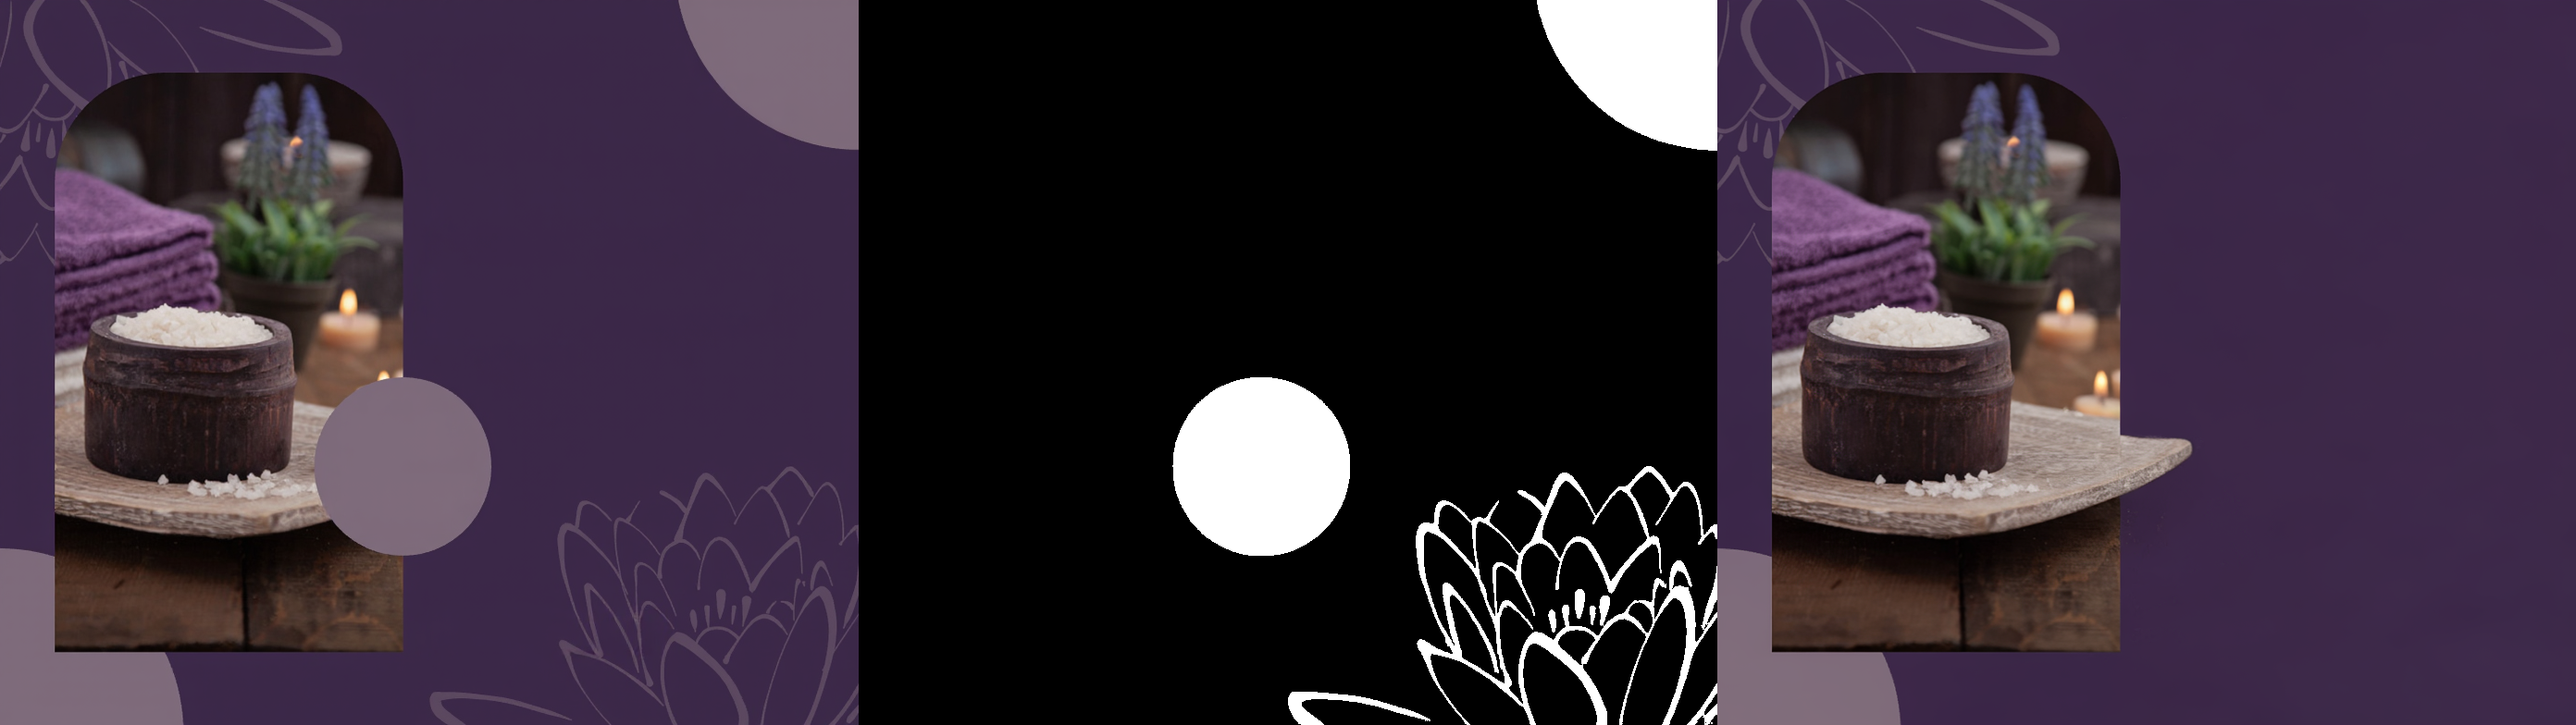

100%|██████████| 20/20 [00:31<00:00,  1.59s/it]


[stop] no fg mask at iter 1
[done] outputs saved under: /home/ubuntu/DiffSynth-Studio/output/qwen_decomposition/iterative_google_object_eraser
[done] error log: /home/ubuntu/DiffSynth-Studio/output/qwen_decomposition/iterative_google_object_eraser/iterative_google_object_eraser_errors.log


In [11]:
# Iterative FG-seg -> Google Object Eraser loop
import os
import sys
import traceback
from datetime import datetime
from pathlib import Path

import torch
from IPython.display import display
from PIL import Image

from diffsynth.pipelines.qwen_image import QwenImagePipeline, ModelConfig

EVAL_ROOT = Path("/home/ubuntu/ml-hub/inpainting/evaluation").resolve()
if str(EVAL_ROOT) not in sys.path:
    sys.path.insert(0, str(EVAL_ROOT))

try:
    from models import GoogleObjectEraserModel
except Exception as exc:
    raise ImportError(
        "GoogleObjectEraserModel import failed. Install google-genai and verify paths."
    ) from exc


# ----------------------
# Basic config
# ----------------------
# Leave as None to auto-resolve from INPUT_IMAGE_PATH / LAST_ERASED_PATH
TEXT_ERASED_IMAGE_PATH = None
MAX_ITERS = 5
SHOW_PREVIEW = True

# FG-seg config
FG_CUDA_DEVICE_INDEX = 1
FG_PROMPT = "Extract the foreground layer."
FG_STEPS = 20
FG_MASK_THRESHOLD = 20
FG_MIN_PIXELS = 1
FG_USE_LORA = True

DIFFSYNTH_REPO_ROOT = Path(os.environ.get("DIFFSYNTH_REPO_ROOT", "/home/ubuntu/DiffSynth-Studio"))
DIFFSYNTH_MODEL_BASE = Path(os.environ.get("DIFFSYNTH_MODEL_BASE_PATH", "/mnt/local/diffsynth_models"))

FG_LORA_DIR = DIFFSYNTH_REPO_ROOT / "models/train/Qwen-Image-Edit-2511_lora_layered_vae_fg_seg"
FG_LORA_PATH = FG_LORA_DIR / "epoch-0.safetensors"

# Google Object Eraser config (see ml-hub/inpainting/evaluation/evaluate.py)
GOOGLE_PROJECT = os.environ.get("GOOGLE_CLOUD_PROJECT", "mesmerizing-bee-477507-g7")
GOOGLE_LOCATION = os.environ.get("GOOGLE_CLOUD_LOCATION", "us-central1")
GOOGLE_EDIT_MODEL = "imagen-3.0-capability-001"
GOOGLE_PROMPT = ""
GOOGLE_NEGATIVE_PROMPT = None
GOOGLE_MASK_DILATION = None
GOOGLE_PERSON_GENERATION = "ALLOW_ALL"
GOOGLE_SAFETY_FILTER = "BLOCK_MEDIUM_AND_ABOVE"
GOOGLE_GUIDANCE_SCALE = None
GOOGLE_SEED = None
GOOGLE_ADD_WATERMARK = False

OUTPUT_ROOT = globals().get("OUTPUT_ROOT", DIFFSYNTH_REPO_ROOT / "output/qwen_decomposition")
ERASED_DIR = globals().get("ERASED_DIR", OUTPUT_ROOT / "erased")
ERASED_DIR.mkdir(parents=True, exist_ok=True)
ITER_OUTPUT_ROOT = OUTPUT_ROOT / "iterative_google_object_eraser"
ITER_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
ERROR_LOG_PATH = ITER_OUTPUT_ROOT / "iterative_google_object_eraser_errors.log"


# ----------------------
# Helpers
# ----------------------
if "_model_config_local_only" not in globals():
    def _model_config_local_only(local_glob: str, label: str) -> ModelConfig:
        import glob

        paths = sorted(glob.glob(local_glob))
        if not paths:
            raise FileNotFoundError(f"[model] Missing local weights for {label}: {local_glob}")
        path_value = paths if len(paths) > 1 else paths[0]
        print(f"[model] Using local weights: {path_value}")
        return ModelConfig(path=path_value)

if "_aux_config_local_only" not in globals():
    def _aux_config_local_only(local_dir: Path, label: str) -> ModelConfig:
        if not local_dir.exists():
            raise FileNotFoundError(f"[aux] Missing local assets for {label}: {local_dir}")
        print(f"[aux] Using local assets: {local_dir}")
        return ModelConfig(path=str(local_dir))


def _composite_side_by_side(images: list[Image.Image]) -> Image.Image:
    heights = [img.height for img in images]
    target_height = max(heights)

    resized: list[Image.Image] = []
    for img in images:
        if img.height == target_height:
            resized.append(img)
        else:
            new_width = max(1, int(round(img.width * (target_height / img.height))))
            resample = Image.NEAREST if img.mode == "L" else Image.LANCZOS
            resized.append(img.resize((new_width, target_height), resample))

    total_width = sum(img.width for img in resized)
    composite = Image.new("RGB", (total_width, target_height))
    offset = 0
    for img in resized:
        paste_img = img if img.mode == "RGB" else Image.merge("RGB", (img, img, img))
        composite.paste(paste_img, (offset, 0))
        offset += paste_img.width
    return composite


def _log_error(stage: str, exc: Exception) -> None:
    timestamp = datetime.now().isoformat(timespec="seconds")
    message = f"[{timestamp}] stage={stage} error={exc}\n{traceback.format_exc()}\n"
    with ERROR_LOG_PATH.open("a") as f:
        f.write(message)
    print(f"[error] {stage}: {exc} (see {ERROR_LOG_PATH})")


def _resolve_text_erased_path() -> Path:
    if TEXT_ERASED_IMAGE_PATH:
        return Path(TEXT_ERASED_IMAGE_PATH)
    if "LAST_ERASED_PATH" in globals():
        candidate = Path(str(globals()["LAST_ERASED_PATH"]))
        if candidate.exists():
            return candidate
    if "INPUT_IMAGE_PATH" in globals():
        input_path = Path(str(globals()["INPUT_IMAGE_PATH"]))
        return ERASED_DIR / f"{input_path.stem}_erased.png"
    raise FileNotFoundError(
        "TEXT_ERASED_IMAGE_PATH is not set. Update INPUT_IMAGE_PATH or set TEXT_ERASED_IMAGE_PATH."
    )


def build_fg_seg_pipeline(device_index: int = FG_CUDA_DEVICE_INDEX) -> QwenImagePipeline:
    if torch.cuda.is_available():
        torch.cuda.set_device(device_index)
        fg_device = f"cuda:{device_index}"
        fg_dtype = torch.bfloat16
    else:
        fg_device = "cpu"
        fg_dtype = torch.float32

    print(f"[fg] device: {fg_device}")

    qwen_root = DIFFSYNTH_MODEL_BASE / "Qwen"
    pipe = QwenImagePipeline.from_pretrained(
        torch_dtype=fg_dtype,
        device=fg_device,
        model_configs=[
            _model_config_local_only(
                str(qwen_root / "Qwen-Image-Edit-2511" / "transformer" / "diffusion_pytorch_model-*.safetensors"),
                "Qwen-Image-Edit-2511 transformer",
            ),
            _model_config_local_only(
                str(qwen_root / "Qwen-Image" / "text_encoder" / "model*.safetensors"),
                "Qwen-Image text encoder",
            ),
            _model_config_local_only(
                str(qwen_root / "Qwen-Image-Layered" / "vae" / "diffusion_pytorch_model.safetensors"),
                "Qwen-Image-Layered VAE",
            ),
        ],
        tokenizer_config=None,
        processor_config=_aux_config_local_only(
            qwen_root / "Qwen-Image-Edit" / "processor",
            "Qwen-Image-Edit processor",
        ),
    )

    if FG_USE_LORA:
        if FG_LORA_DIR.is_dir():
            lora_candidates = sorted(FG_LORA_DIR.glob("*.safetensors"), key=lambda p: p.stat().st_mtime)
            if not lora_candidates:
                raise FileNotFoundError(f"No LoRA checkpoints found in: {FG_LORA_DIR}")
            lora_path = lora_candidates[-1]
        else:
            lora_path = FG_LORA_PATH

        if not lora_path.exists():
            raise FileNotFoundError(f"LoRA checkpoint not found: {lora_path}")

        print(f"[fg] Using LoRA: {lora_path}")
        pipe.load_lora(pipe.dit, str(lora_path))

    return pipe


def run_fg_seg_mask(image_path: Path, pipe: QwenImagePipeline, seed: int | None) -> Image.Image:
    edit_image = Image.open(image_path).convert("RGBA")
    width, height = edit_image.size

    result = pipe(
        FG_PROMPT,
        edit_image=edit_image,
        seed=seed,
        num_inference_steps=FG_STEPS,
        height=height,
        width=width,
        edit_image_auto_resize=False,
        zero_cond_t=True,
    )

    output_rgba = result.convert("RGBA")
    alpha = output_rgba.getchannel("A")
    mask = alpha.point(lambda v: 255 if v > FG_MASK_THRESHOLD else 0)

    if mask.size != edit_image.size:
        mask = mask.resize(edit_image.size, Image.NEAREST)

    return mask


# ----------------------
# Run loop
# ----------------------
resolved_path = _resolve_text_erased_path()
if not resolved_path.exists():
    raise FileNotFoundError(f"Input text-erased image not found: {resolved_path}")

if "fg_pipe_google" not in globals():
    if "fg_pipe" in globals():
        fg_pipe_google = fg_pipe
    else:
        fg_pipe_google = build_fg_seg_pipeline()

try:
    google_model = GoogleObjectEraserModel(
        project=GOOGLE_PROJECT,
        location=GOOGLE_LOCATION,
        edit_model=GOOGLE_EDIT_MODEL,
        prompt=GOOGLE_PROMPT,
        negative_prompt=GOOGLE_NEGATIVE_PROMPT,
        mask_dilation=GOOGLE_MASK_DILATION,
        person_generation=GOOGLE_PERSON_GENERATION,
        safety_filter_level=GOOGLE_SAFETY_FILTER,
        guidance_scale=GOOGLE_GUIDANCE_SCALE,
        seed=GOOGLE_SEED,
        add_watermark=GOOGLE_ADD_WATERMARK,
    )
    google_model.load_model()
except Exception as exc:
    _log_error("google_init", exc)
    raise

current_path = resolved_path
base_seed = globals().get("SEED", 123)

for i in range(MAX_ITERS):
    iter_dir = ITER_OUTPUT_ROOT / f"iter_{i:02d}"
    iter_dir.mkdir(parents=True, exist_ok=True)

    try:
        mask = run_fg_seg_mask(current_path, fg_pipe_google, seed=base_seed + i)
    except Exception as exc:
        _log_error(f"fg-seg iter={i}", exc)
        break

    fg_pixels = mask.histogram()[255]
    if fg_pixels < FG_MIN_PIXELS:
        print(f"[stop] no fg mask at iter {i}")
        break

    mask_path = iter_dir / f"{current_path.stem}_fg_mask.png"
    mask.save(mask_path)

    try:
        input_image = Image.open(current_path).convert("RGB")
        seed_value = GOOGLE_SEED if GOOGLE_SEED is not None else base_seed + i
        google_model.seed = seed_value
        output_image = google_model.predict(input_image, mask)
    except Exception as exc:
        _log_error(f"google_eraser iter={i}", exc)
        break

    output_path = iter_dir / f"{current_path.stem}_google_erased.png"
    output_image.save(output_path)

    mask_vis = mask.resize(input_image.size, Image.NEAREST)
    output_resized = output_image.resize(input_image.size, Image.LANCZOS)
    composite = _composite_side_by_side([input_image, mask_vis, output_resized])

    composite_path = iter_dir / f"{current_path.stem}_composite.png"
    composite.save(composite_path)

    print(f"[done] iter {i}: {composite_path}")
    if SHOW_PREVIEW:
        display(composite)

    current_path = output_path

print(f"[done] outputs saved under: {ITER_OUTPUT_ROOT}")
print(f"[done] error log: {ERROR_LOG_PATH}")


In [10]:
import os
os.environ["GOOGLE_CLOUD_PROJECT"] = "lica-398204"
os.environ["GOOGLE_CLOUD_LOCATION"] = "us-central1"